# PROYECTO MÓDULO 8 CIENCIA DE DATOS

# Proyecto: Clasificador Inteligente de Imágenes de Ropa

# Reinaldo Elgueta A.

## LECCIÓN 1:LA RED NEURONAL ARTIFICIAL


📌 Objetivo: Comprender los elementos de una red neuronal artificial y
su rol en la resolución de problemas.


📍 Tareas a desarrollar:


- Definir la arquitectura de una red neuronal densa.
- Implementar una red neuronal simple para clasificación binaria.
- Identificar capas, pesos, funciones de activación y pérdida.

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# ------------------1. Clasificación Binaria-------------------
# Implementación de red neuronal simple para clasificación binaria

# Datos simples: ¿El número es mayor o igual a 3?
X_bin = np.array([[0], [1], [2], [3], [4], [5]])
y_bin = np.array([0, 0, 0, 1, 1, 1]) # 0 = No, 1 = Sí

# Arquitectura de Red Neuronal Simple (Binaria)

model_binario = keras.Sequential([
    keras.Input(shape=(1,)),                          # Capa de Entrada (Input)
    layers.Dense(4, activation='relu'),               # Capa Oculta con pesos y ReLU
    layers.Dense(1, activation='sigmoid')             # Capa de Salida con Sigmoide
])

model_binario.compile(
    optimizer='adam',
    loss='binary_crossentropy',                       # Función de pérdida binaria
    metrics=['accuracy']
)

model_binario.fit(X_bin, y_bin, epochs=100, verbose=0)
print("Modelo Binario entrenado con éxito.")

# ------------------1. Arquitectura para StyleNet (Fashion-MNIST) -------------------
#  Definimos la arquitectura de una red neuronal densa para el problema multiclase de la tienda virtual.

# Carga de datos para el proyecto StyleNet
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Normalización (Escalar píxeles de 0-255 a 0-1)
train_images = train_images / 255.0

# Definición de la arquitectura densa para StyleNet
model_stylenet = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),             # Capa para 'aplanar' la imagen
    layers.Dense(128, activation='relu'),             # Capa oculta con 128 neuronas
    layers.Dense(10, activation='softmax')            # Capa de salida: 10 categorías de ropa
])

model_stylenet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',           # Pérdida para múltiples categorías
    metrics=['accuracy']
)

# Resumen para identificar capas y parámetros (pesos)
model_stylenet.summary()

Modelo Binario entrenado con éxito.


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## LECCIÓN 2: DEEP LEARNING


📌 Objetivo: Reconocer las principales arquitecturas, usos y frameworks
de Deep Learning.


📍 Tareas a desarrollar:


- Investigar y documentar la arquitectura óptima para clasificación de imágenes.
- Justificar la elección entre red densa vs. convolutiva.
- Seleccionar el framework a utilizar: Keras o PyTorch.


### DESARROLLO

1. **Investigación: Arquitectura óptima para clasificación de imágenes**

Para el problema de StyleNet, que implica procesar imágenes de productos subidos por usuarios (Fashion-MNIST) , la arquitectura óptima es una Red Neuronal Convolucional (CNN).

A diferencia de las redes densas, las CNN están diseñadas específicamente para imitar el sistema visual humano. Utilizan capas de filtros que se deslizan sobre la imagen para detectar características espaciales de forma jerárquica:

- ***Capas iniciales:*** Detectan bordes, líneas y texturas simples de la prenda.
- ***Capas intermedias:*** Identifican formas más complejas como cuellos de camisas o cordones de zapatillas.
- ***Capas finales:*** Combinan estas formas para clasificar el objeto completo en una de las 10 categorías.

2. **Justificación: Red Densa (ANN) vs. Red Convolutiva (CNN)**

Para este proyecto, se justifica la transición de la red densa (implementada en la Lección 1) a una convolutiva por las siguientes razones técnicas:

- ***Invariancia espacial:*** Una red densa (ANN) ve la imagen como un vector rígido. Si una zapatilla se mueve unos píxeles de posición, la ANN falla. La CNN, mediante la operación de convolución, reconoce el objeto sin importar su ubicación exacta en la imagen.
- ***Preservación de la estructura:*** La red densa "aplana" la imagen, perdiendo la relación entre píxeles vecinos. La CNN mantiene la relación 2D, lo cual es vital para entender la geometría de una prenda de ropa.
- ***Eficiencia de parámetros:*** Como vimos en tu summary() de la Lección 1, una red densa genera miles de parámetros rápidamente (101,770 para una imagen pequeña). Las CNN usan "compartición de pesos", lo que permite modelos más profundos y potentes con menos riesgo de sobreajuste.

3. **Selección del Framework: Keras**

Se ha seleccionado Keras (corriendo sobre TensorFlow) como el framework principal para el desarrollo del prototipo funcional.
Motivos de la elección:
- ***Productividad:*** Keras permite un prototipado rápido y legible, lo cual es ideal para los tiempos de entrega del módulo.
- ***Ecosistema:*** Su integración nativa con Google Colab y la facilidad para cargar el dataset Fashion-MNIST optimizan el flujo de trabajo.
- ***Documentación: ***Cuenta con una de las comunidades más grandes, asegurando soporte técnico para la implementación de métricas y regularización como Dropout

## LECCIÓN 3:IMPLEMENTACIÓN DE RN EN PYTHON


📌 Objetivo: Diseñar y entrenar una red neuronal con Python para
resolver un problema de clasificación.


📍 Tareas a desarrollar:

- Implementar un modelo funcional para clasificar imágenes del dataset Fashion-MNIST.
- Entrenar y validar el modelo usando diferentes hiperparámetros.
- Aplicar técnicas de optimización y regularización.

In [6]:
from tensorflow.keras import layers, models

# 1. Definición del modelo con Regularización (Dropout)
model_final = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2), # Técnica de regularización: apaga el 20% de neuronas al azar
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

# 2. Compilación con Optimizador
model_final.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Entrenamiento y Validación
# Usaremos 20 épocas para observar el comportamiento de las métricas
history = model_final.fit(
    train_images, train_labels,
    epochs=20,
    validation_split=0.2, # Separamos 20% para validar mientras entrena
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7986 - loss: 0.5586 - val_accuracy: 0.8493 - val_loss: 0.4113
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8481 - loss: 0.4169 - val_accuracy: 0.8673 - val_loss: 0.3705
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8592 - loss: 0.3818 - val_accuracy: 0.8708 - val_loss: 0.3587
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8695 - loss: 0.3552 - val_accuracy: 0.8720 - val_loss: 0.3506
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8749 - loss: 0.3415 - val_accuracy: 0.8727 - val_loss: 0.3439
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8779 - loss: 0.3275 - val_accuracy: 0.8775 - val_loss: 0.3339
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8808 - loss: 0.3157 - val_accuracy: 0.8773 - val_loss: 0.3299
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8857 - loss: 0

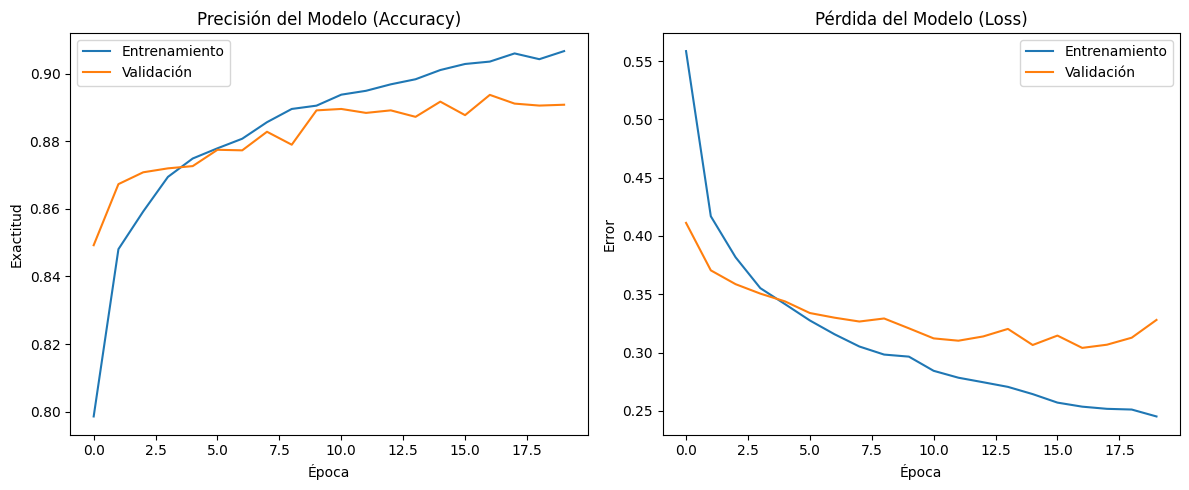

In [7]:
import matplotlib.pyplot as plt

# Configurar el gráfico
plt.figure(figsize=(12, 5))

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.legend()

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo (Loss)')
plt.xlabel('Época')
plt.ylabel('Error')
plt.legend()

plt.tight_layout()
plt.show()

## LECCIÓN 4: REDES NEURONALES CONVOLUTIVAS

📌 Objetivo: Integrar una red convolutiva para mejorar la capacidad predictiva
del modelo.

📍 Tareas a desarrollar:

-  Rediseñar la arquitectura utilizando CNN.
- Evaluar y comparar los resultados con el modelo anterior.
- Generar predicciones visuales sobre imágenes externas.

In [8]:
#---------------------------------------------------------------------
#-------------------ARQUITECTURA DE CNN-------------------------------
#---------------------------------------------------------------------

model_cnn = models.Sequential([
    # Primera capa convolucional: Detecta bordes y texturas
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Segunda capa convolucional: Detecta formas más complejas
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Capa de clasificación final
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Ajustar las dimensiones de las imágenes para la CNN (necesitan el canal de color: 1 para escala de grises)
train_images_cnn = train_images.reshape((60000, 28, 28, 1))
test_images_cnn = test_images.reshape((10000, 28, 28, 1))

print("Arquitectura CNN lista para entrenamiento.")

Arquitectura CNN lista para entrenamiento.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
#---------------------------------------------------------------------
# ----------------- ENTRENAMIENTO DE LA CNN --------------------------
#---------------------------------------------------------------------
history_cnn = model_cnn.fit(
    train_images_cnn, train_labels,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9809 - loss: 0.0498 - val_accuracy: 0.9061 - val_loss: 0.4518
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.9837 - loss: 0.0435 - val_accuracy: 0.9070 - val_loss: 0.4522
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 34ms/step - accuracy: 0.9846 - loss: 0.0426 - val_accuracy: 0.9063 - val_loss: 0.4669
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9849 - loss: 0.0414 - val_accuracy: 0.9082 - val_loss: 0.4591
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9874 - loss: 0.0354 - val_accuracy: 0.9035 - val_loss: 0.5338
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9854 - loss: 0.0393 - val_accuracy: 0.9063 - val_loss: 0.5505
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9880 - loss: 0.0328 - val_accuracy: 0.9091 - val_loss: 0.5333
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9891 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


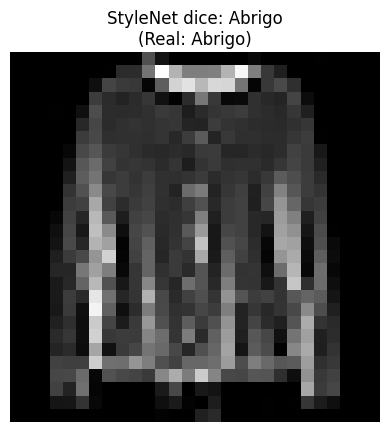

In [14]:
#---------------------------------------------------------------------
#---------------------GENERAR PREDICCIONES VISUALES ------------------
#---------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

# 1. Definir los nombres de las categorías (esto es lo que faltaba)
class_names = ['Camiseta', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

# 2. Seleccionar una imagen al azar del set de prueba (ejemplo índice 25)
idx = 25
test_img = test_images_cnn[idx].reshape(1, 28, 28, 1)

# 3. Realizar la predicción con tu modelo CNN
prediccion = model_cnn.predict(test_img)
clase_predicha = class_names[np.argmax(prediccion)]
clase_real = class_names[test_labels[idx]]

# 4. Visualización del resultado final
plt.imshow(test_images[idx], cmap='gray')
plt.title(f"StyleNet dice: {clase_predicha}\n(Real: {clase_real})")
plt.axis('off')
plt.show()